QUESTION 1

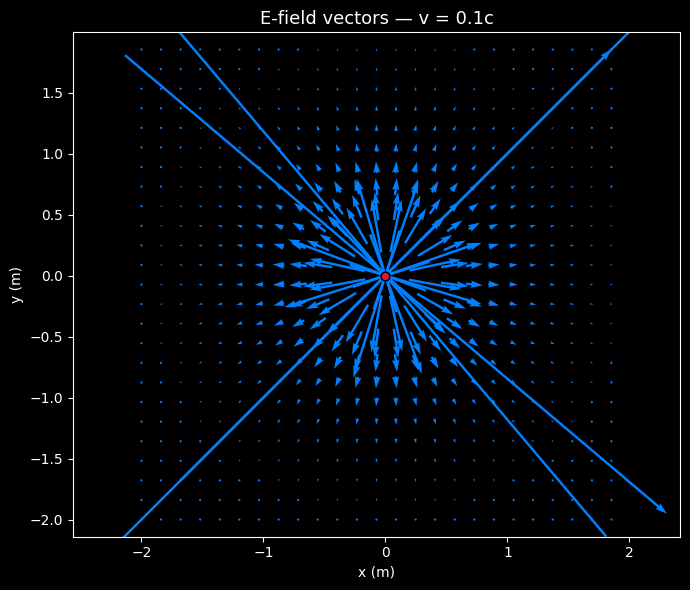

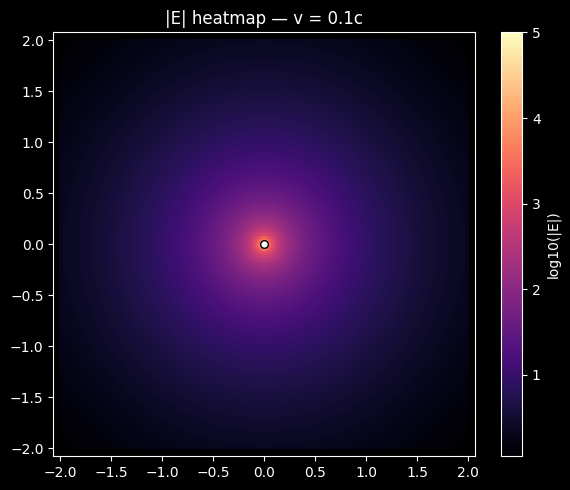

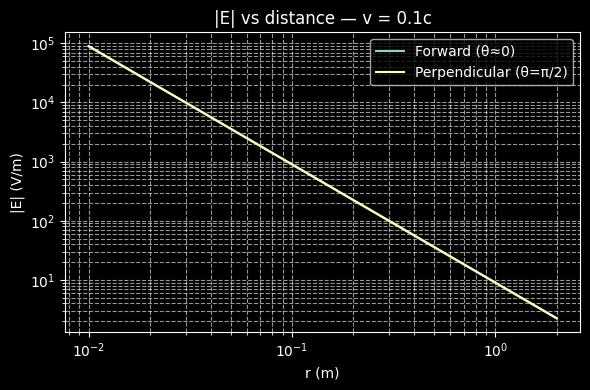

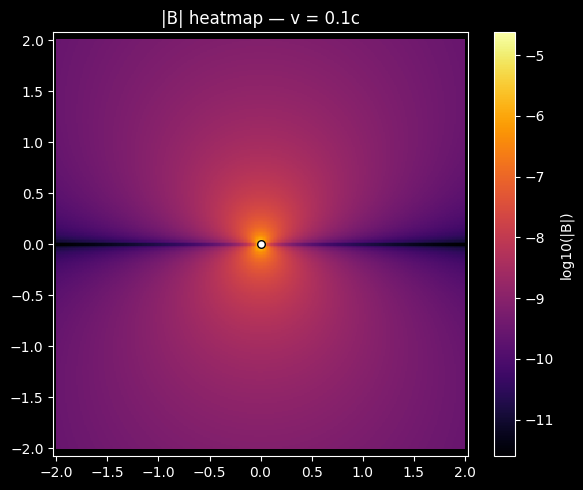

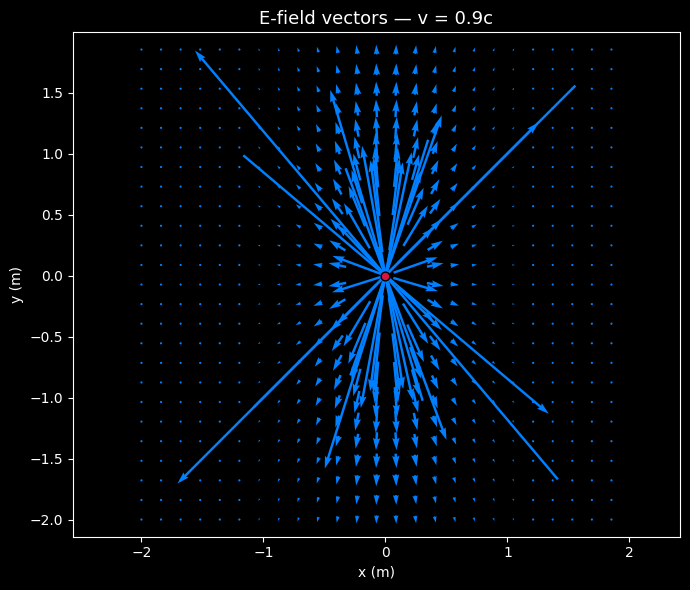

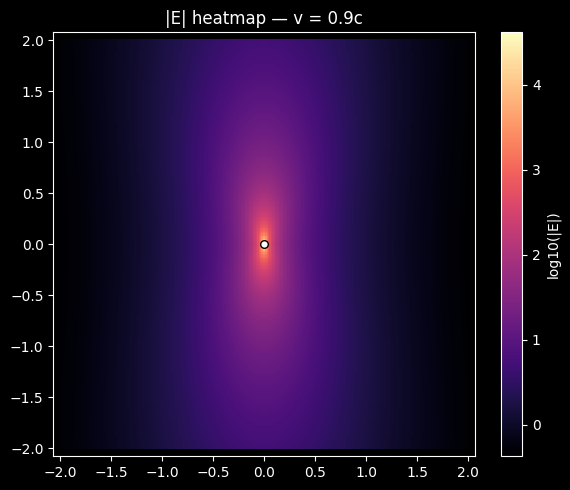

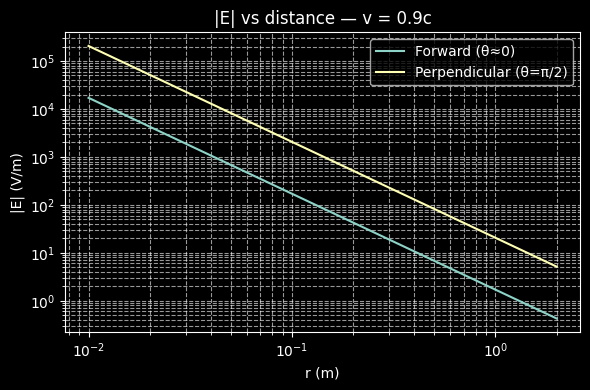

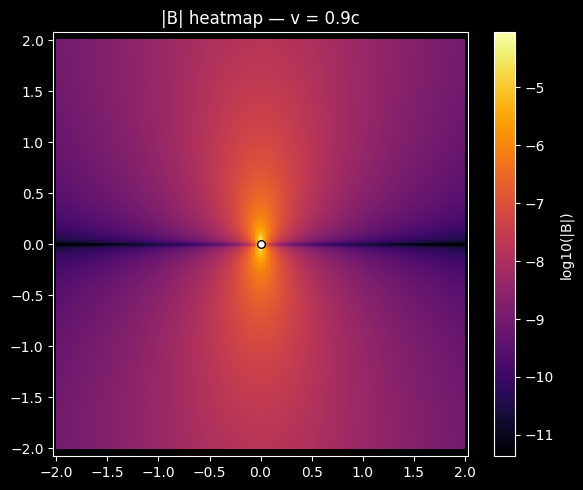

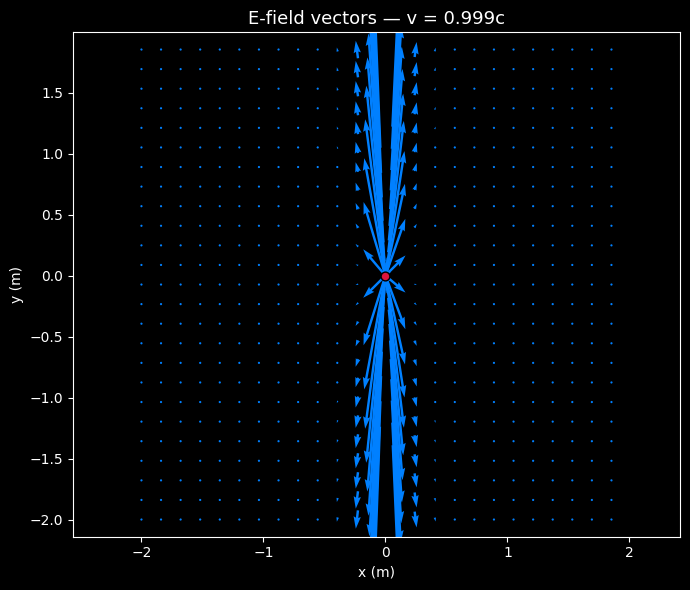

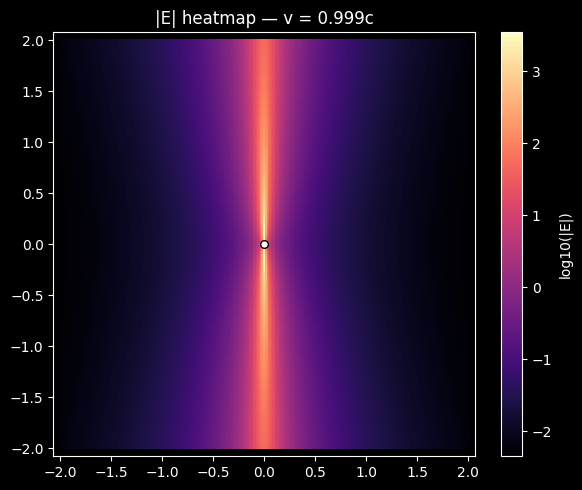

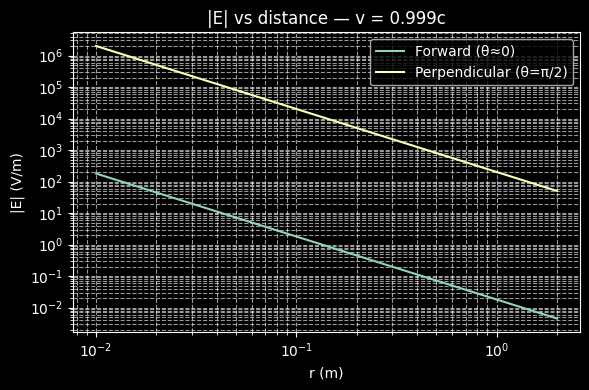

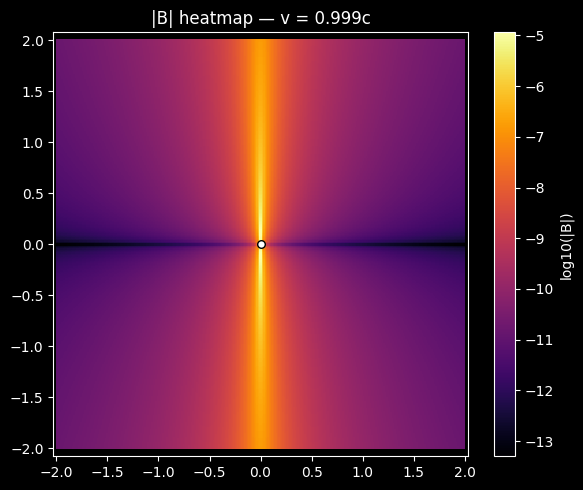

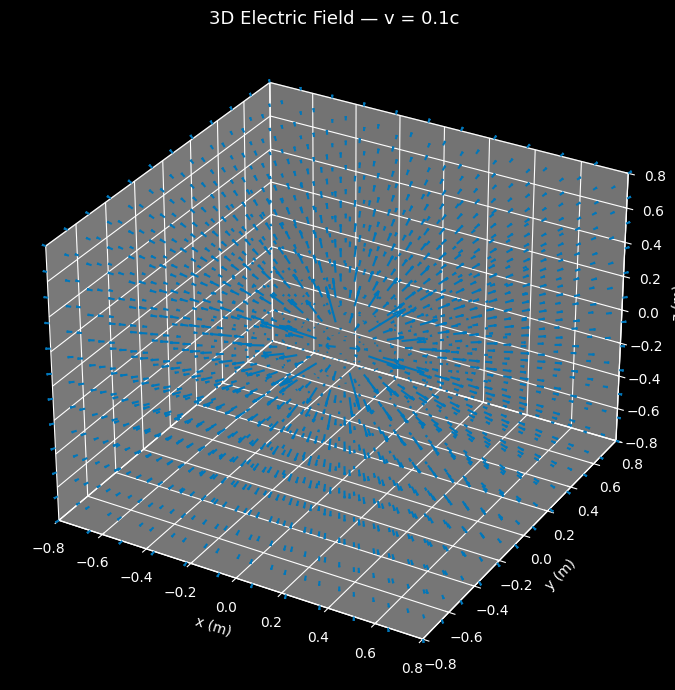

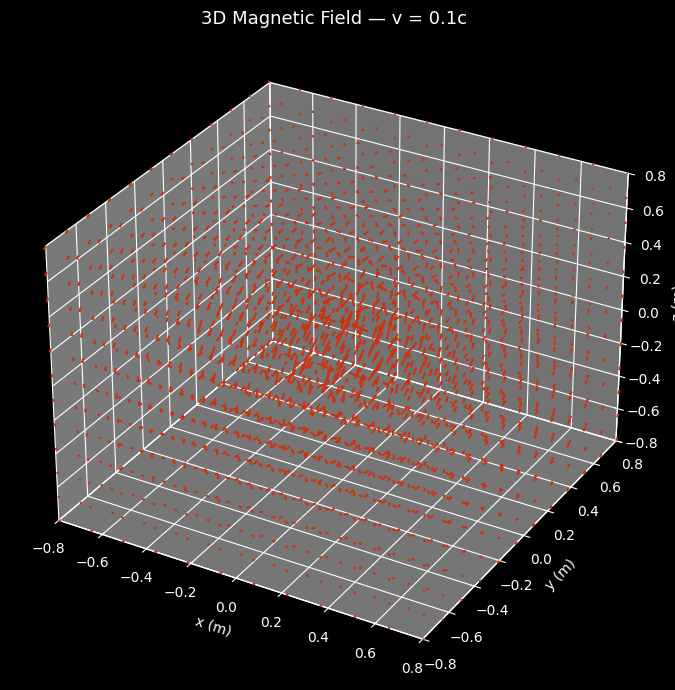

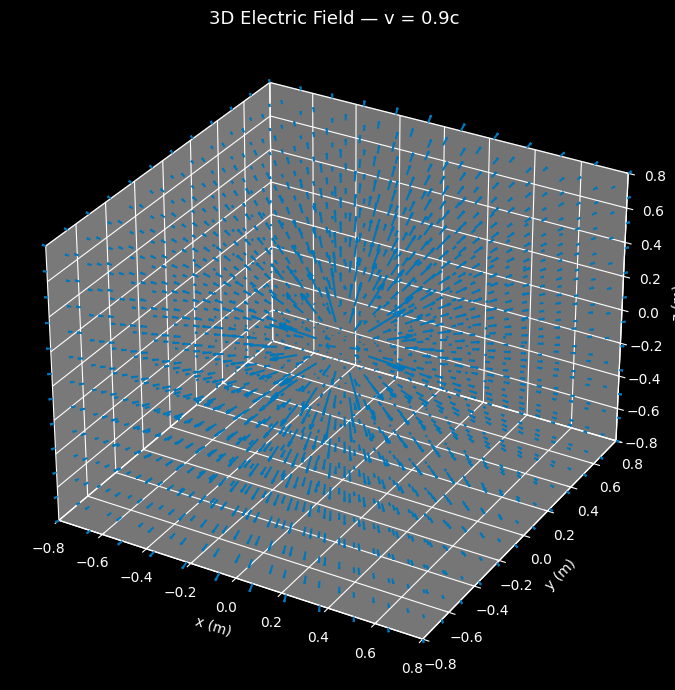

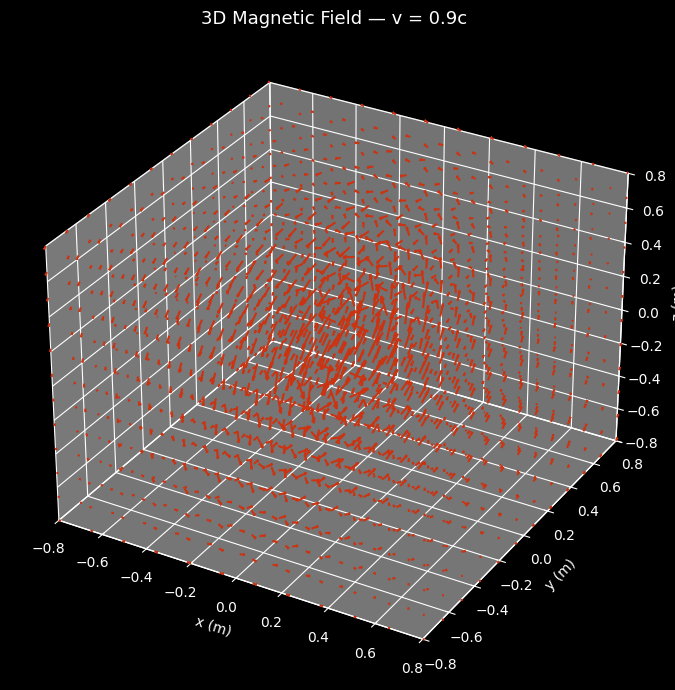

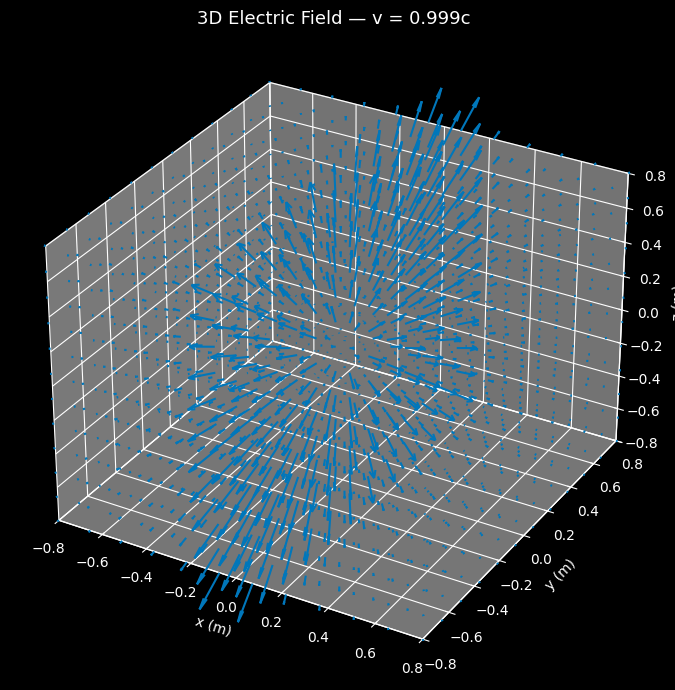

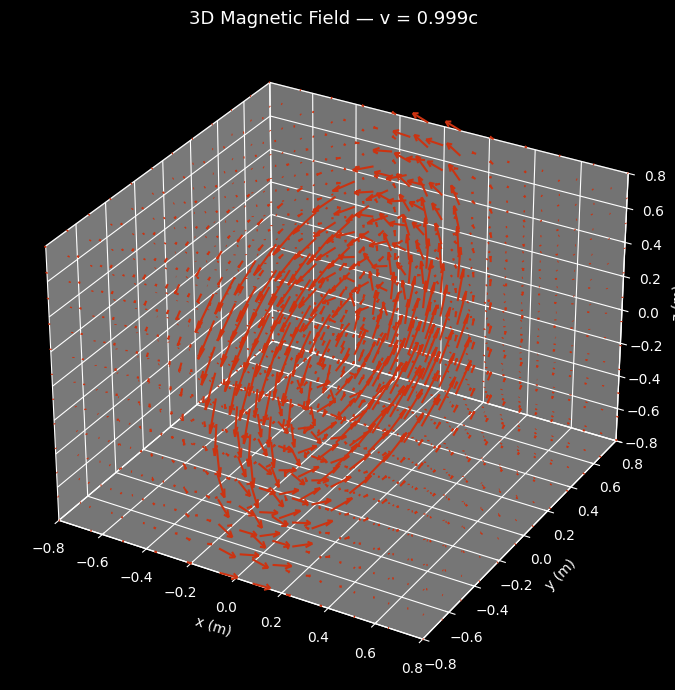

In [10]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

q = 1e-9
grid_halfwidth = 2.0
n_grid = 300
N3D = 12
L3D = 0.8
length3d = 0.18
mask_cutoff = 0.06
MAG_MAPPING = 'sqrt'
QUIVER_SUBSAMPLE = 12
QUIVER_WIDTH = 0.004
SHOW_PLOTS = True
eps0 = 8.8541878128e-12
c = 299792458.0

def get_E(q, vx, X, Y, Z=None):
    beta = vx / c
    b2 = beta**2
    if Z is None: Rx, Ry, Rz = X, Y, np.zeros_like(X)
    else: Rx, Ry, Rz = X, Y, Z
    R = np.sqrt(Rx**2 + Ry**2 + Rz**2)
    R_safe = np.where(R == 0.0, 1e-20, R)
    Rperp2 = Ry**2 + Rz**2
    sin2 = Rperp2 / (R_safe**2)
    denom = np.maximum(1.0 - b2 * sin2, 1e-20)
    pref = (q / (4.0 * np.pi * eps0)) * (1.0 - b2) / (denom ** 1.5)
    Ex = pref * (Rx / (R_safe**3))
    Ey = pref * (Ry / (R_safe**3))
    Ez = pref * (Rz / (R_safe**3))
    return (Ex, Ey) if Z is None else (Ex, Ey, Ez)

def get_B(vx, Ex, Ey, Ez=None):
    if Ez is None: Ez = np.zeros_like(Ex)
    Bx = np.zeros_like(Ex)
    By = - (vx * Ez) / (c**2)
    Bz = (vx * Ey) / (c**2)
    return Bx, By, Bz

def mag_map(mag, mapping='sqrt'):
    mag = np.array(mag, dtype=float)
    mag[mag < 0] = 0.0
    if mapping == 'linear': mapped = mag
    elif mapping == 'sqrt': mapped = np.sqrt(mag)
    elif mapping == 'log':
        mapped = np.log10(mag + 1e-40)
        mapped = mapped - np.nanmin(mapped)
    else: raise ValueError("bad mapping type")
    maxv = np.nanmax(mapped)
    return np.zeros_like(mapped) if maxv == 0 else mapped / float(maxv)

def radial_E(q, vx, r, theta):
    if np.isclose(theta, 0.0): theta = 1e-8
    Rx = r * np.cos(theta)
    Ry = r * np.sin(theta)
    Ex, Ey = get_E(q, vx, Rx, Ry)
    return np.sqrt(Ex**2 + Ey**2)

speeds = [0.1 * c, 0.9 * c, 0.999 * c]
labels = ["0.1c", "0.9c", "0.999c"]

x = np.linspace(-grid_halfwidth, grid_halfwidth, n_grid)
y = np.linspace(-grid_halfwidth, grid_halfwidth, n_grid)
X2, Y2 = np.meshgrid(x, y)

r_min, r_max, n_r = 0.01, grid_halfwidth, 800
r_array = np.linspace(r_min, r_max, n_r)
directions = {"Forward (θ≈0)": 0.0, "Perpendicular (θ=π/2)": np.pi / 2}

for vx, label in zip(speeds, labels):
    Ex2, Ey2 = get_E(q, vx, X2, Y2)
    E_mag2 = np.sqrt(Ex2**2 + Ey2**2)
    Bx2, By2, Bz2 = get_B(vx, Ex2, Ey2)
    Bmag2 = np.sqrt(Bx2**2 + By2**2 + Bz2**2)
    if not SHOW_PLOTS: continue

    plt.figure(figsize=(7,6))
    s = QUIVER_SUBSAMPLE
    plt.quiver(X2[::s,::s], Y2[::s,::s], Ex2[::s,::s], Ey2[::s,::s],
               color="#0080FF", width=QUIVER_WIDTH, pivot='mid')
    plt.scatter(0,0,color='crimson',s=40,edgecolor='black',zorder=5)
    plt.title(f"E-field vectors — v = {label}", fontsize=13)
    plt.xlabel("x (m)"); plt.ylabel("y (m)")
    plt.axis('equal'); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    plt.pcolormesh(X2, Y2, np.log10(E_mag2 + 1e-30), shading='auto', cmap='magma')
    plt.colorbar(label='log10(|E|)')
    plt.scatter(0,0,color='white',s=30,edgecolor='black')
    plt.title(f"|E| heatmap — v = {label}")
    plt.axis('equal'); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,4))
    for dlabel, theta in directions.items():
        E_line = radial_E(q, vx, r_array, theta)
        plt.loglog(r_array, E_line, label=dlabel)
    plt.xlabel("r (m)"); plt.ylabel("|E| (V/m)")
    plt.title(f"|E| vs distance — v = {label}")
    plt.grid(True,which='both',ls='--',alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    plt.pcolormesh(X2, Y2, np.log10(Bmag2 + 1e-40), shading='auto', cmap='inferno')
    plt.colorbar(label='log10(|B|)')
    plt.scatter(0,0,color='white',s=30,edgecolor='black')
    plt.title(f"|B| heatmap — v = {label}")
    plt.axis('equal'); plt.tight_layout(); plt.show()

x3 = np.linspace(-L3D, L3D, N3D)
y3 = np.linspace(-L3D, L3D, N3D)
z3 = np.linspace(-L3D, L3D, N3D)
X3, Y3, Z3 = np.meshgrid(x3, y3, z3, indexing='xy')
R3 = np.sqrt(X3**2 + Y3**2 + Z3**2)
mask3 = R3 > mask_cutoff

for vx, label in zip(speeds, labels):
    Ex3, Ey3, Ez3 = get_E(q, vx, X3, Y3, Z3)
    Ex3_mask = np.where(mask3, Ex3, 0.0)
    Ey3_mask = np.where(mask3, Ey3, 0.0)
    Ez3_mask = np.where(mask3, Ez3, 0.0)
    Bx3, By3, Bz3 = get_B(vx, Ex3_mask, Ey3_mask, Ez3_mask)

    E3_mag = np.sqrt(Ex3_mask**2 + Ey3_mask**2 + Ez3_mask**2)
    B3_mag = np.sqrt(Bx3**2 + By3**2 + Bz3**2)
    E_map = mag_map(E3_mag, mapping=MAG_MAPPING)
    B_map = mag_map(B3_mag, mapping=MAG_MAPPING)

    E3_safe = np.where(E3_mag == 0, 1.0, E3_mag)
    B3_safe = np.where(B3_mag == 0, 1.0, B3_mag)

    Ex_s = (Ex3_mask / E3_safe) * (E_map * length3d)
    Ey_s = (Ey3_mask / E3_safe) * (E_map * length3d)
    Ez_s = (Ez3_mask / E3_safe) * (E_map * length3d)
    Bx_s = (Bx3 / B3_safe) * (B_map * length3d)
    By_s = (By3 / B3_safe) * (B_map * length3d)
    Bz_s = (Bz3 / B3_safe) * (B_map * length3d)

    step3 = max(1, N3D // 8)
    Xs, Ys, Zs = X3[::step3,::step3,::step3], Y3[::step3,::step3,::step3], Z3[::step3,::step3,::step3]
    Exs, Eys, Ezs = Ex_s[::step3,::step3,::step3], Ey_s[::step3,::step3,::step3], Ez_s[::step3,::step3,::step3]
    Bxs, Bys, Bzs = Bx_s[::step3,::step3,::step3], By_s[::step3,::step3,::step3], Bz_s[::step3,::step3,::step3]
    mask_sub = mask3[::step3,::step3,::step3]

    Xe, Ye, Ze = Xs[mask_sub], Ys[mask_sub], Zs[mask_sub]
    Ue, Ve, We = Exs[mask_sub], Eys[mask_sub], Ezs[mask_sub]
    Xb, Yb, Zb = Xs[mask_sub], Ys[mask_sub], Zs[mask_sub]
    Ub, Vb, Wb = Bxs[mask_sub], Bys[mask_sub], Bzs[mask_sub]

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(Xe, Ye, Ze, Ue, Ve, We, length=1.0, normalize=False, color="#0077BB")
    ax.set_xlim(-L3D, L3D); ax.set_ylim(-L3D, L3D); ax.set_zlim(-L3D, L3D)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
    ax.set_title(f"3D Electric Field — v = {label}", fontsize=13)
    plt.tight_layout(); plt.show()

    figb = plt.figure(figsize=(8,7))
    axb = figb.add_subplot(111, projection='3d')
    axb.quiver(Xb, Yb, Zb, Ub, Vb, Wb, length=1.0, normalize=False, color="#CC3311")
    axb.set_xlim(-L3D, L3D); axb.set_ylim(-L3D, L3D); axb.set_zlim(-L3D, L3D)
    axb.set_xlabel('x (m)'); axb.set_ylabel('y (m)'); axb.set_zlabel('z (m)')
    axb.set_title(f"3D Magnetic Field — v = {label}", fontsize=13)
    plt.tight_layout(); plt.show()


**QUESTION 2**

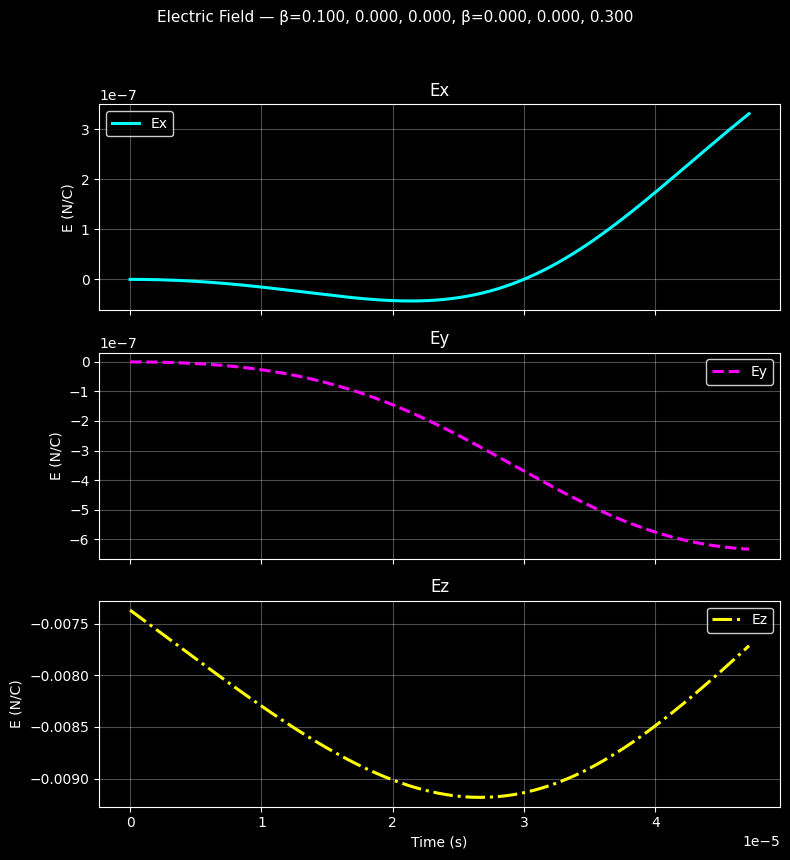

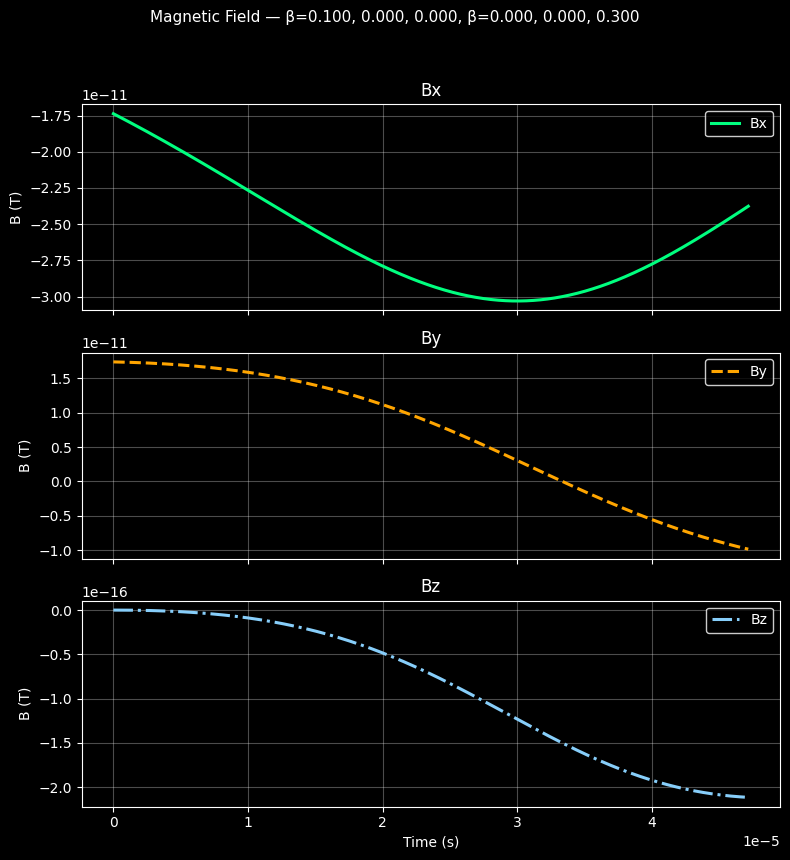

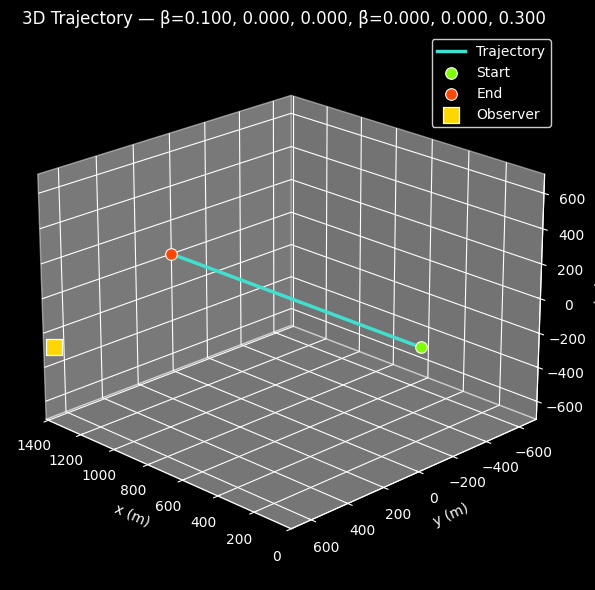

|E| = 7.8136e-03,   c|B| = 7.8136e-03


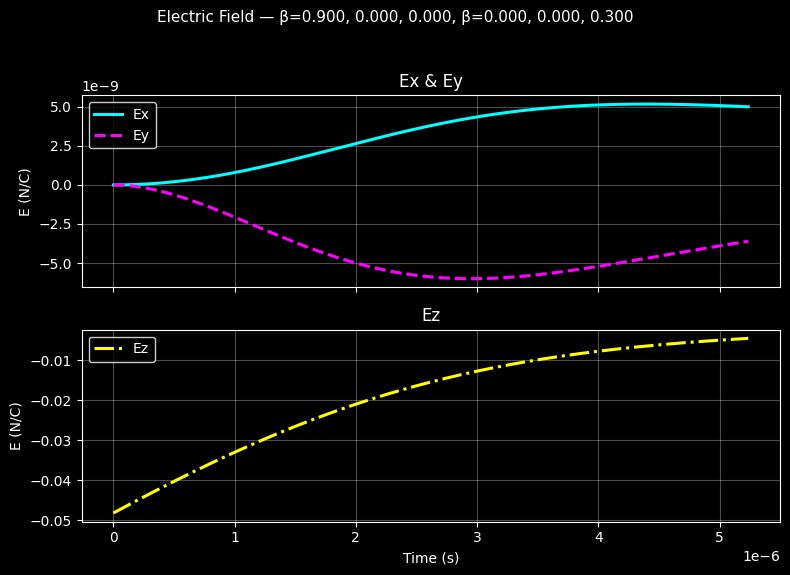

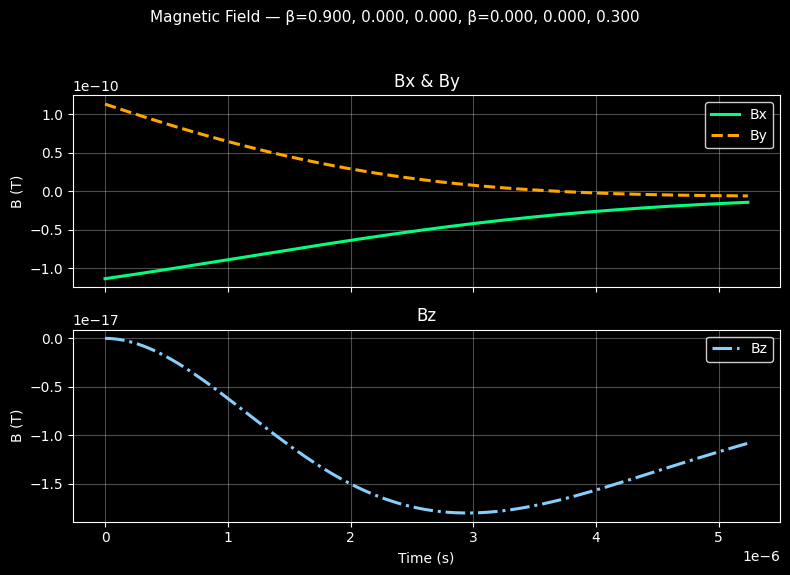

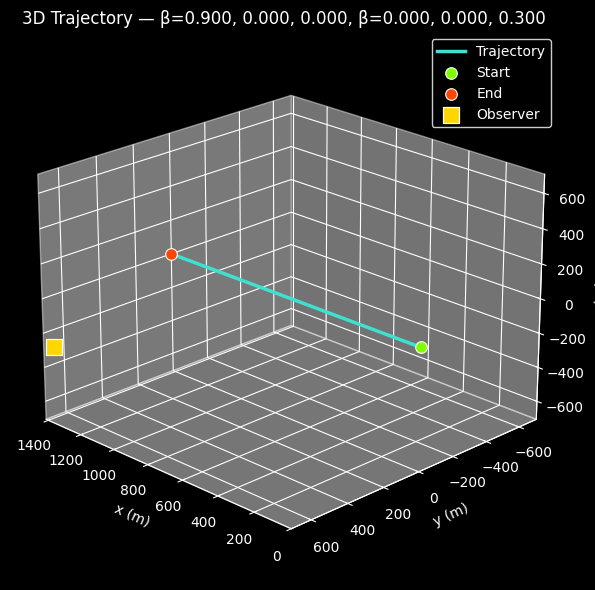

|E| = 3.9887e-02,   c|B| = 3.9887e-02


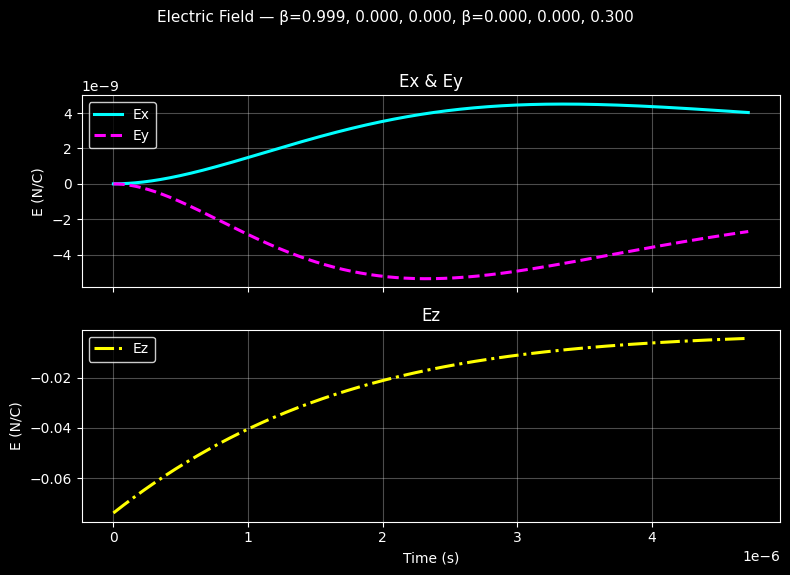

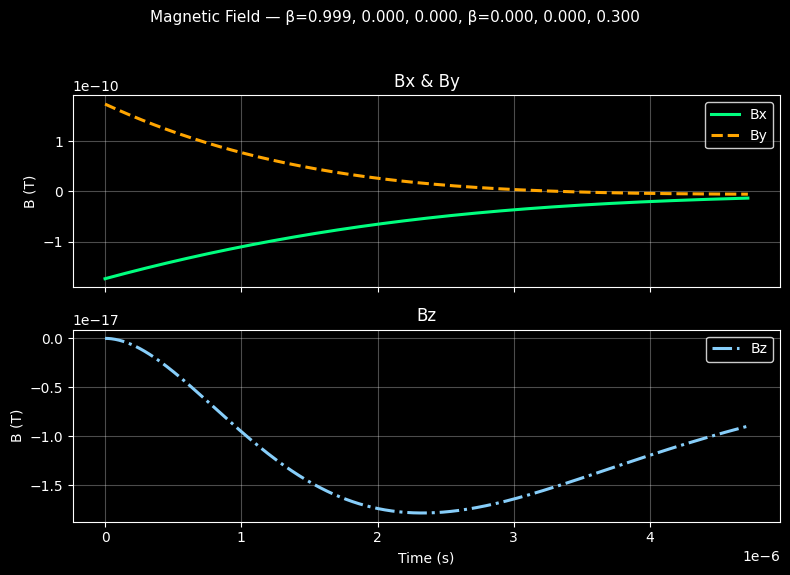

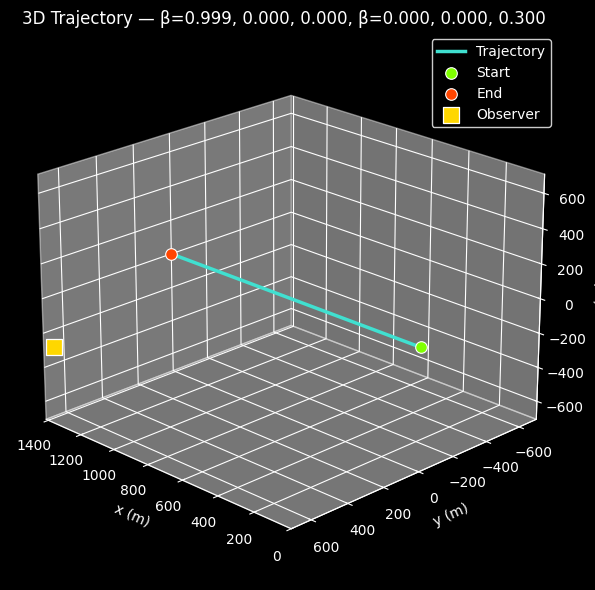

|E| = 5.5974e-02,   c|B| = 5.5974e-02


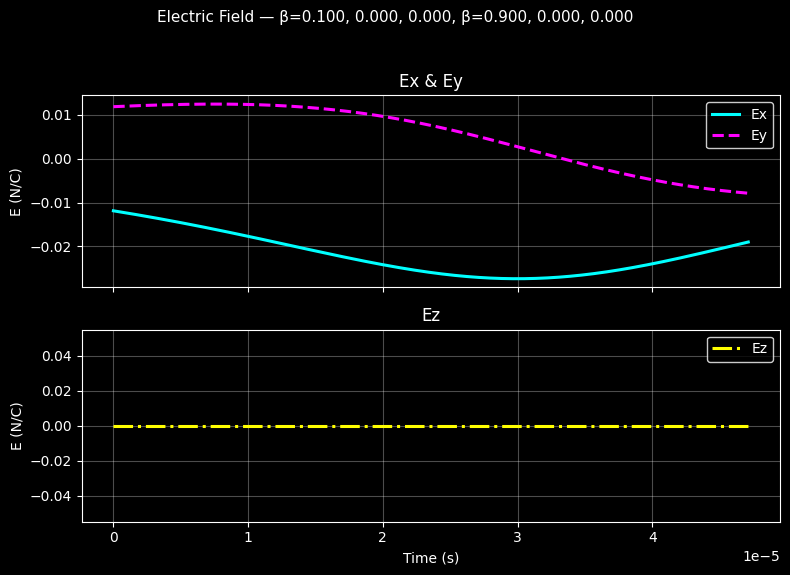

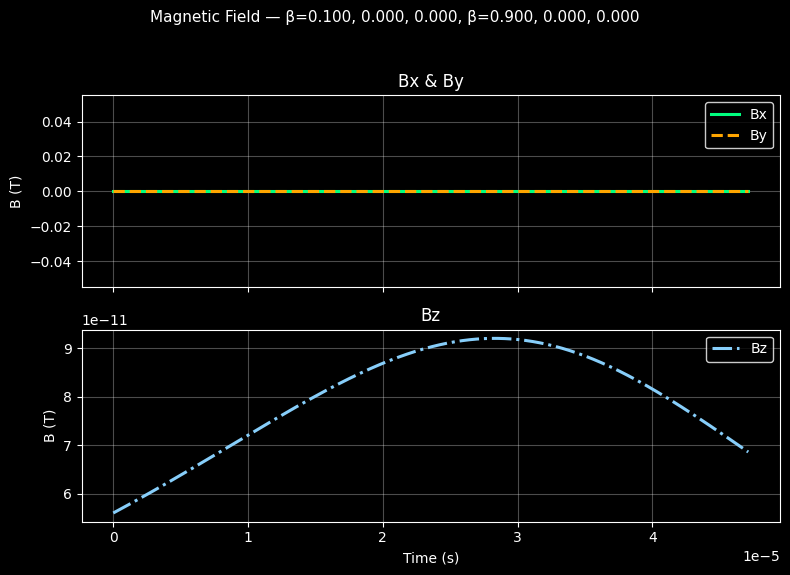

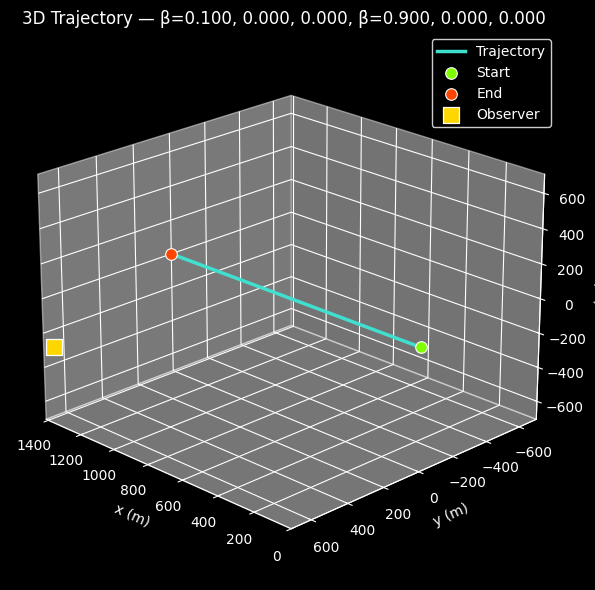

|E| = 1.9025e-02,   c|B| = 1.9025e-02


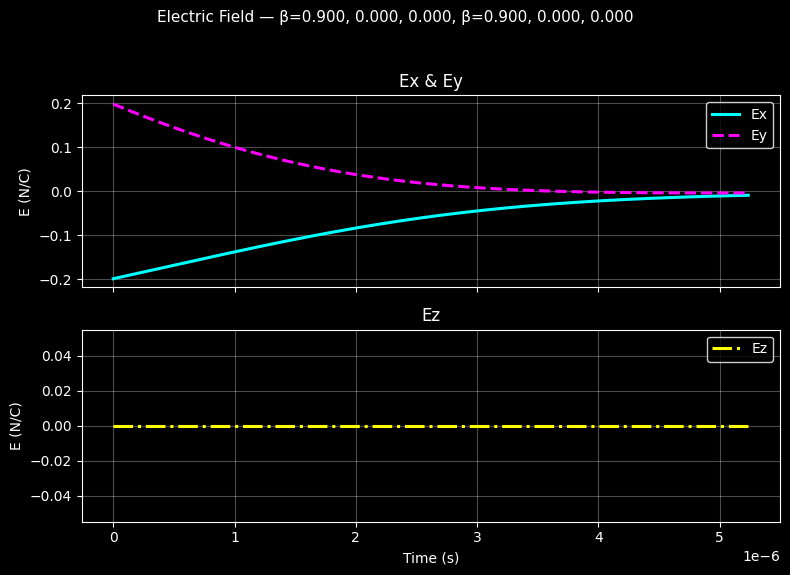

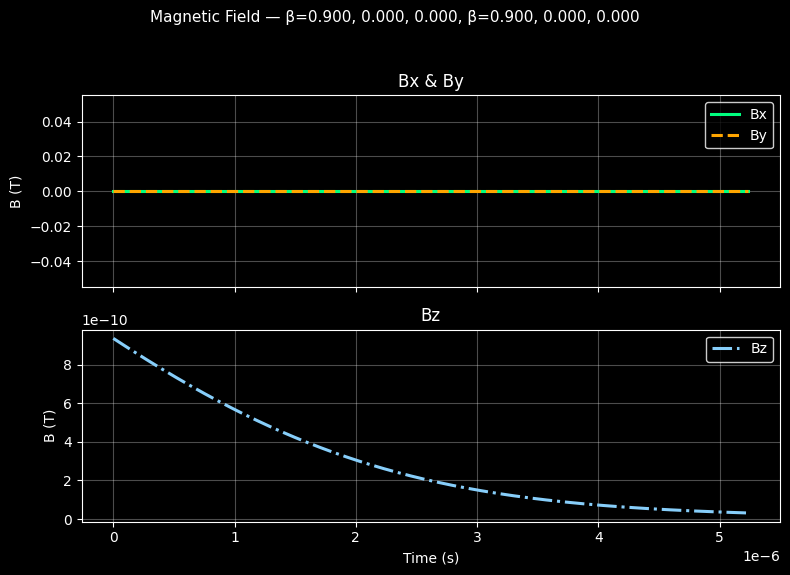

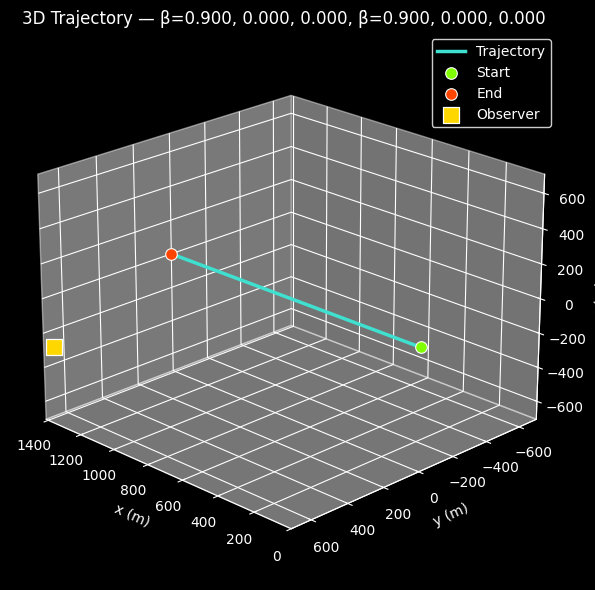

|E| = 2.1943e-01,   c|B| = 2.1943e-01


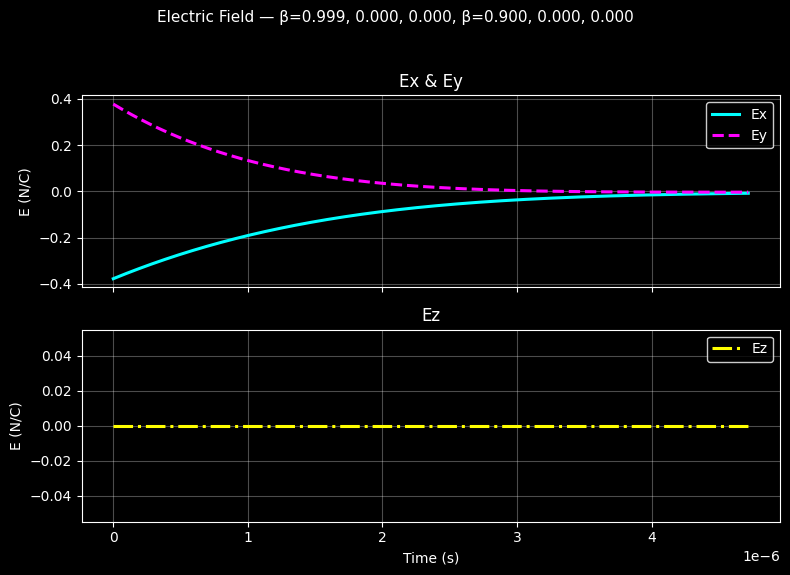

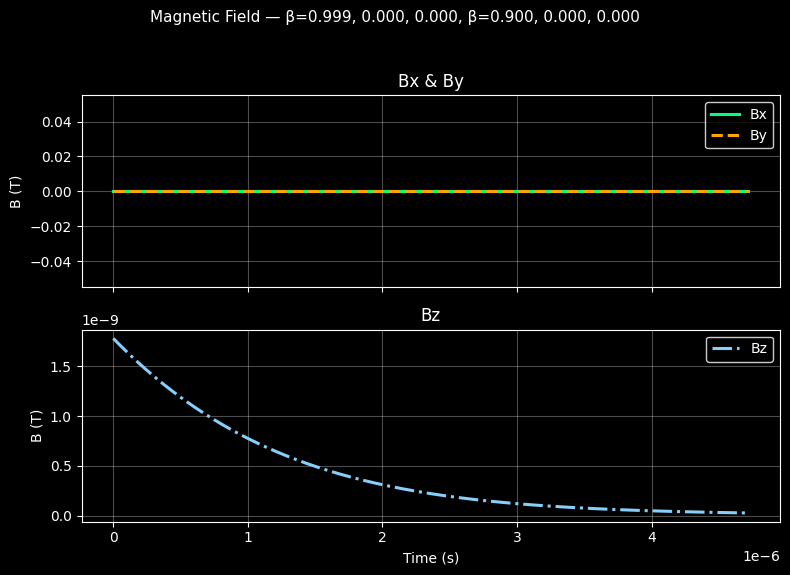

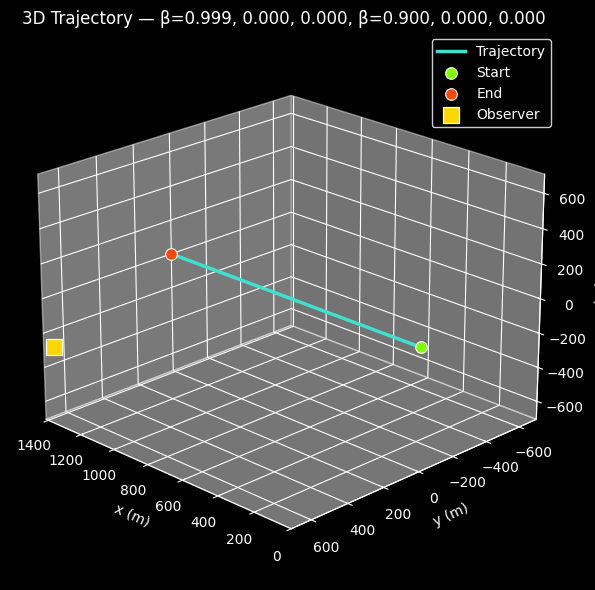

|E| = 3.6479e-01,   c|B| = 3.6479e-01


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("dark_background")

def compute_trajectory(beta, beta_dot, c=3e8, max_distance=1414.0):
    def displacement(t):
        pos = c * (beta * t + 0.5 * beta_dot * t**2)
        return np.linalg.norm(pos)

    def target(t):
        return displacement(t) - max_distance

    t_guess = (1 - np.linalg.norm(beta)) / (np.linalg.norm(beta_dot) + 1e-12)
    result = root_scalar(target, bracket=[0, t_guess], method='brentq')
    T = result.root

    t = np.linspace(0, T, 1000)
    r = c * (np.outer(beta, t) + 0.5 * np.outer(beta_dot, t**2))
    return t, r[0], r[1], r[2]

def compute_fields(beta, beta_dot, obs, q=1.0, c=3e8, k=9e9):
    t, x, y, z = compute_trajectory(beta, beta_dot, c)
    E = np.zeros((len(t), 3))
    B = np.zeros((len(t), 3))
    for i in range(len(t)):
        r_vec = obs - np.array([x[i], y[i], z[i]])
        R = np.linalg.norm(r_vec)
        n = r_vec / R
        b_inst = beta + beta_dot * t[i]
        numerator = np.cross(n, np.cross((n - b_inst), beta_dot))
        denominator = (1 - np.dot(n, b_inst))**3 * R
        E[i] = (q * k / c) * numerator / denominator
        B[i] = np.cross(n, E[i]) / c
    return t, E, B, x, y, z

def cluster_components(arrays, threshold=0.4):
    eps = 1e-20
    ranges = [max(np.ptp(a), eps) for a in arrays]
    remaining = set(range(len(arrays)))
    groups = []
    while remaining:
        i = remaining.pop()
        group = [i]
        for j in list(remaining):
            rel_diff = abs(ranges[i] - ranges[j]) / max(ranges[i], ranges[j])
            if rel_diff < threshold:
                group.append(j)
                remaining.remove(j)
        groups.append(sorted(group))
    groups.sort(key=lambda g: g[0])
    return groups

def plot_fields(beta, beta_dot, obs, threshold=0.4):
    t, E, B, x, y, z = compute_fields(beta, beta_dot, obs)

    E_labels, B_labels = ['Ex', 'Ey', 'Ez'], ['Bx', 'By', 'Bz']
    E_colors, B_colors = ['#00FFFF', '#FF00FF', '#FFFF00'], ['#00FF7F', '#FFA500', '#87CEFA']
    line_styles = ['-', '--', '-.']

    groups_E = cluster_components(E.T, threshold)
    groups_B = cluster_components(B.T, threshold)
    fmt = lambda arr: ", ".join(f"{v:.3f}" for v in arr)

    # ---------- Electric Field ----------
    figE, axesE = plt.subplots(len(groups_E), 1, figsize=(8, 3 * len(groups_E)), sharex=True, facecolor='black')
    axesE = np.atleast_1d(axesE)
    for ax, group in zip(axesE, groups_E):
        for idx in group:
            ax.plot(t, E[:, idx], line_styles[idx], color=E_colors[idx], lw=2.2, label=E_labels[idx])
        ax.legend(facecolor='black', edgecolor='white')
        ax.grid(True, alpha=0.3)
        ax.set_ylabel("E (N/C)")
        ax.set_title(" & ".join([E_labels[i] for i in group]))
    axesE[-1].set_xlabel("Time (s)")
    figE.suptitle(f"Electric Field — β={fmt(beta)}, β̇={fmt(beta_dot)}", fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # ---------- Magnetic Field ----------
    figB, axesB = plt.subplots(len(groups_B), 1, figsize=(8, 3 * len(groups_B)), sharex=True, facecolor='black')
    axesB = np.atleast_1d(axesB)
    for ax, group in zip(axesB, groups_B):
        for idx in group:
            ax.plot(t, B[:, idx], line_styles[idx], color=B_colors[idx], lw=2.2, label=B_labels[idx])
        ax.legend(facecolor='black', edgecolor='white')
        ax.grid(True, alpha=0.3)
        ax.set_ylabel("B (T)")
        ax.set_title(" & ".join([B_labels[i] for i in group]))
    axesB[-1].set_xlabel("Time (s)")
    figB.suptitle(f"Magnetic Field — β={fmt(beta)}, β̇={fmt(beta_dot)}", fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # ---------- 3D Trajectory ----------
    fig = plt.figure(figsize=(7, 6), facecolor='black')
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, '-', color='#40E0D0', lw=2.5, label='Trajectory')
    ax.scatter(x[0], y[0], z[0], color='#7FFF00', s=70, edgecolors='white', lw=0.8, label='Start')
    ax.scatter(x[-1], y[-1], z[-1], color='#FF4500', s=70, edgecolors='white', lw=0.8, label='End')
    ax.scatter(obs[0], obs[1], obs[2], color='#FFD700', s=120, marker='s', edgecolors='white', lw=0.9, label='Observer')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    ax.set_title(f"3D Trajectory — β={fmt(beta)}, β̇={fmt(beta_dot)}")
    ax.legend(facecolor='black', edgecolor='white')
    ax.view_init(elev=22, azim=135)
    max_range = np.ptp([x, y, z]).max()
    mid = np.array([(a.max() + a.min()) / 2 for a in (x, y, z)])
    for i, set_lim in enumerate([ax.set_xlim, ax.set_ylim, ax.set_zlim]):
        set_lim(mid[i] - max_range / 2, mid[i] + max_range / 2)
    plt.tight_layout()
    plt.show()

    idx = len(t)//10
    print(f"|E| = {np.linalg.norm(E[idx]):.4e},   c|B| = {3e8 * np.linalg.norm(B[idx]):.4e}")

if __name__ == "__main__":
    observer = np.array([1000, 1000, 0])
    for v in [0.1, 0.9, 0.999]:
        beta = np.array([v, 0, 0])
        beta_dot = np.array([0, 0, 0.3])
        plot_fields(beta, beta_dot, observer)
    for v in [0.1, 0.9, 0.999]:
        beta = np.array([v, 0, 0])
        beta_dot = np.array([0.9, 0, 0])
        plot_fields(beta, beta_dot, observer)


QUESTION 3 (I)

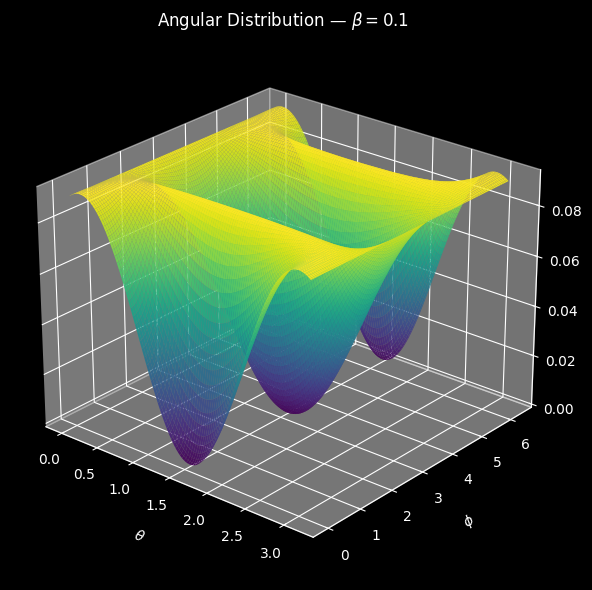

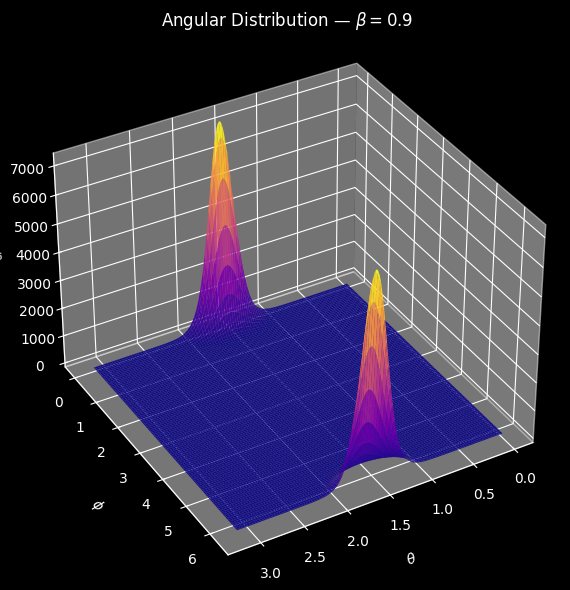

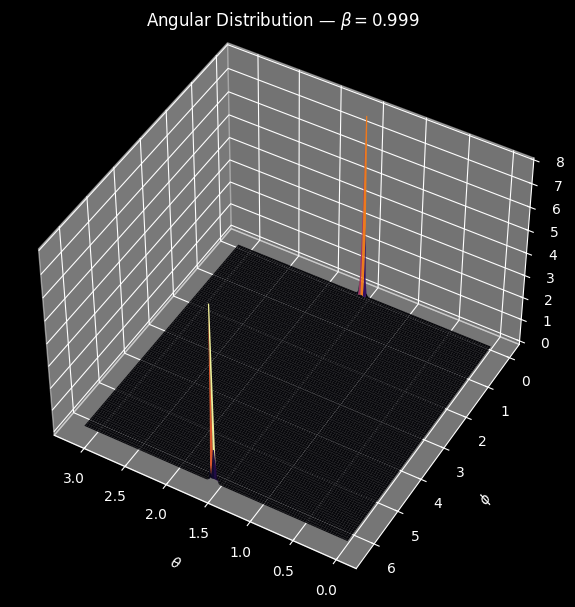

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

dot_b = 0.3
dot_b2 = dot_b**2
betas = [0.1, 0.9, 0.999]
titles = [r"$\beta = 0.1$", r"$\beta = 0.9$", r"$\beta = 0.999$"]

th = np.linspace(0, np.pi, 220)
ph = np.linspace(0, 2*np.pi, 220)
TH, PH = np.meshgrid(th, ph)

def ang_dist(b, TH, PH):
    s, c = np.sin(TH), np.cos(TH)
    cp, sp = np.cos(PH), np.sin(PH)
    d = (1 - b * s * cp)
    d = np.where(np.abs(d) < 1e-9, np.sign(d)*1e-9, d)
    num = (1 - b * s * cp)**2 * (c**2 + s**2 * sp**2) + (b**2) * s**4 * cp**2
    return dot_b2 * num / d**5

cmaps = ["viridis", "plasma", "inferno"]
angles = [(25, -50), (35, 60), (45, 120)]

for b, t, cmap, view in zip(betas, titles, cmaps, angles):
    Z = ang_dist(b, TH, PH)
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d')
    X, Y = TH, PH
    ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, rstride=2, cstride=2, alpha=0.95)
    ax.set_title(f"Angular Distribution — {t}", fontsize=12, color="white")
    ax.set_xlabel(r"$\theta$", color="white")
    ax.set_ylabel(r"$\phi$", color="white")
    ax.set_zlabel(r"$\frac{dP}{d\Omega}$", color="white")
    ax.view_init(*view)
    fig.patch.set_facecolor("black")
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 10
    plt.tight_layout()
    plt.show()


QUESTION 3 (II)

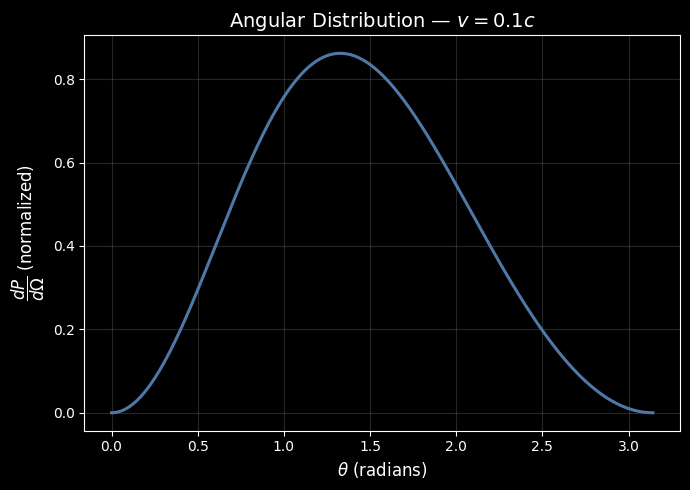

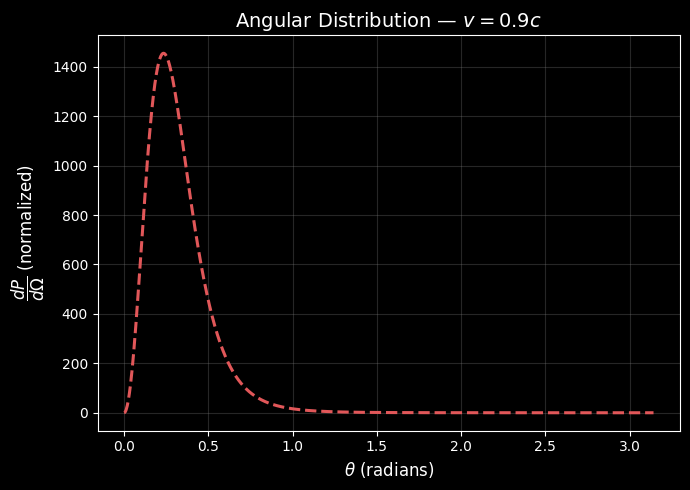

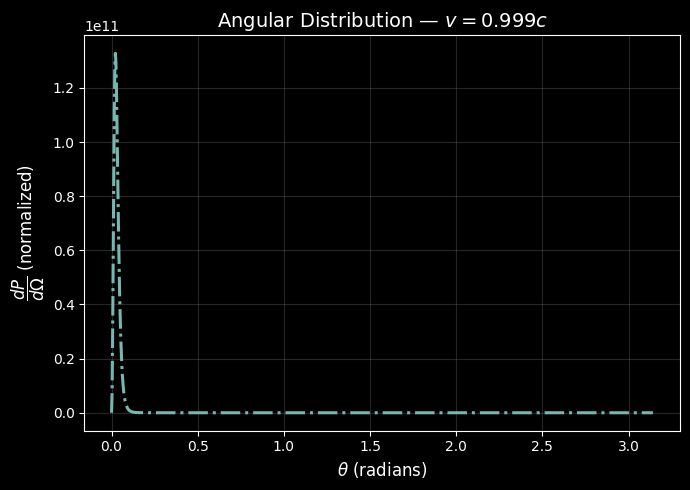

In [9]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, np.pi, 1000)
dot_b = 0.9
k = dot_b**2

def dPdO(beta, th):
    return k * (np.sin(th))**2 / (1 - beta * np.cos(th))**5

betas = [0.1, 0.9, 0.999]
titles = [r"$v = 0.1c$", r"$v = 0.9c$", r"$v = 0.999c$"]
colors = ["#4E79A7", "#E15759", "#76B7B2"]
styles = ["-", "--", "-."]

for b, t, col, st in zip(betas, titles, colors, styles):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(theta, dPdO(b, theta), st, color=col, lw=2.2)
    ax.set_title(f"Angular Distribution — {t}", fontsize=14, color="white")
    ax.set_xlabel(r"$\theta$ (radians)", fontsize=12, color="white")
    ax.set_ylabel(r"$\dfrac{dP}{d\Omega}$ (normalized)", fontsize=12, color="white")
    ax.grid(alpha=0.3, color="gray")
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.tick_params(colors="white")
    plt.tight_layout()
    plt.show()
